In [7]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import fpgrowth, association_rules


In [11]:
df = pd.read_csv("retail_cleaned.csv",low_memory=False)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


In [15]:
df = df[df['Quantity'] > 0]
basket = (
    df
    .groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)


In [17]:
basket = basket > 0


In [19]:
frequent_itemsets = fpgrowth(basket, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)


In [21]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
strong_rules = rules[(rules['confidence'] >= 0.6) & (rules['lift'] >= 1.2)]
strong_rules = strong_rules.sort_values('lift', ascending=False)
strong_rules.head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1557,"(HERB MARKER ROSEMARY, HERB MARKER PARSLEY)",(HERB MARKER THYME),0.010772,0.011874,0.010170,0.944186,79.518791,1.0,0.010042,17.703929,0.998176,0.815261,0.943515,0.900363
1560,(HERB MARKER THYME),"(HERB MARKER ROSEMARY, HERB MARKER PARSLEY)",0.011874,0.010772,0.010170,0.856540,79.518791,1.0,0.010042,6.895504,0.999290,0.815261,0.854978,0.900363
1559,(HERB MARKER ROSEMARY),"(HERB MARKER THYME, HERB MARKER PARSLEY)",0.012024,0.010671,0.010170,0.845833,79.262128,1.0,0.010042,6.417267,0.999400,0.812000,0.844170,0.899442
1558,"(HERB MARKER THYME, HERB MARKER PARSLEY)",(HERB MARKER ROSEMARY),0.010671,0.012024,0.010170,0.953052,79.262128,1.0,0.010042,21.043888,0.998034,0.812000,0.952480,0.899442
1564,"(HERB MARKER THYME, HERB MARKER BASIL)",(HERB MARKER ROSEMARY),0.010521,0.012024,0.010020,0.952381,79.206349,1.0,0.009894,20.747495,0.997873,0.800000,0.951801,0.892857
1565,(HERB MARKER ROSEMARY),"(HERB MARKER THYME, HERB MARKER BASIL)",0.012024,0.010521,0.010020,0.833333,79.206349,1.0,0.009894,5.936874,0.999391,0.800000,0.831561,0.892857
1563,"(HERB MARKER ROSEMARY, HERB MARKER BASIL)",(HERB MARKER THYME),0.010721,0.011874,0.010020,0.934579,78.709728,1.0,0.009893,15.104216,0.997995,0.796813,0.933793,0.889231
1566,(HERB MARKER THYME),"(HERB MARKER ROSEMARY, HERB MARKER BASIL)",0.011874,0.010721,0.010020,0.843882,78.709728,1.0,0.009893,6.336730,0.999159,0.796813,0.842190,0.889231
1548,(HERB MARKER ROSEMARY),(HERB MARKER THYME),0.012024,0.011874,0.011072,0.920833,77.552039,1.0,0.010929,12.481595,0.999119,0.863281,0.919882,0.926661
1549,(HERB MARKER THYME),(HERB MARKER ROSEMARY),0.011874,0.012024,0.011072,0.932489,77.552039,1.0,0.010929,14.634394,0.998967,0.863281,0.931668,0.926661


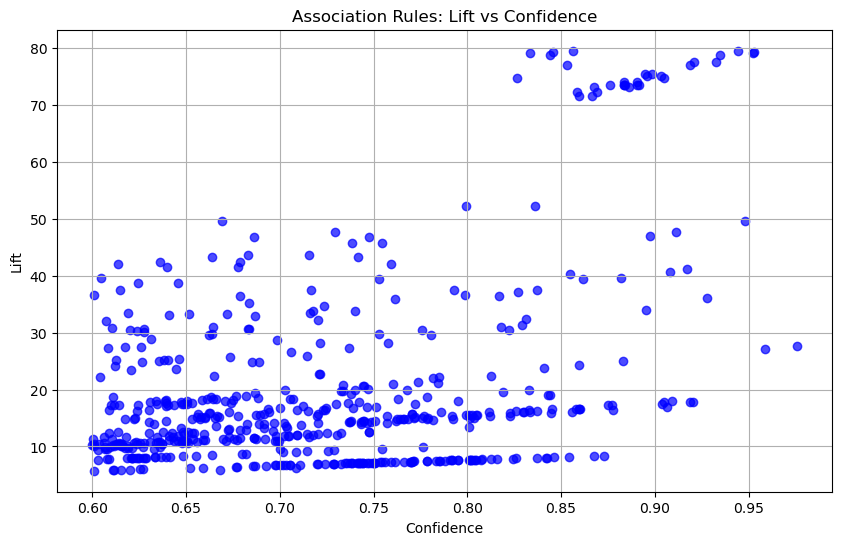

In [25]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(strong_rules['confidence'], strong_rules['lift'], alpha=0.7, c='blue')
plt.title('Association Rules: Lift vs Confidence')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.grid(True)
plt.show()
